
# Regression Discontinuity Design

*A lecture note on identifying causal effects from a known, sharp
assignment rule — no coin flip required.*

---

## 1. Intro: the scholarship you almost didn't get

Imagine a scholarship is awarded to every incoming student who scores 80 or
higher on an entrance exam. Sarah scores 79. Tom scores 81. On paper they
look nearly identical — same school, same year, one point apart on a noisy
test — yet Sarah gets nothing and Tom gets a scholarship. Ten years later,
if Tom is doing noticeably better in his career than Sarah, is that because
of the scholarship, or because Tom was simply a stronger, 81-versus-79-point
student to begin with?

The [fundamental problem of causal inference](../fundamental-problem-of-causal-inference/tutorial.ipynb)
tutorial in this domain showed that the *only* clean way to answer a
question like this is to compare outcomes for people who are, in
expectation, identical except for treatment status — and that randomized
experiments deliver that by construction. Nobody randomized Sarah and Tom's
scholarship, though. **Regression discontinuity design (RDD)** is what you
reach for when treatment isn't randomized, but it *is* handed out by a
known, sharp rule based on a continuous number crossing a threshold. The
key insight: whether you land at 79 or 81 on a noisy exam is essentially
luck — measurement error, which questions happened to come up, how you
slept the night before. Nobody chose to score exactly 79 versus exactly 81
on purpose. So right around the cutoff, the students who "just missed" and
the students who "just made it" are, plausibly, as good as randomly
assigned to each group — even though the exam itself was not random at all.

**By the end of this tutorial you'll be able to:**

- Explain, in plain language and formally, why comparing units just above
  and just below a known cutoff identifies a causal effect.
- Distinguish **sharp** RDD from **fuzzy** RDD, and state the continuity
  assumption that makes sharp RDD valid.
- Explain why RDD only identifies a **local** effect at the cutoff — not an
  average effect for the whole population — and why that scoping limitation
  matters for real policy questions.
- Estimate a real discontinuity using local linear regression with a
  bandwidth, on the canonical Lee (2008) "close elections" dataset, and
  read off an estimate and a standard error.
- Run the standard diagnostic every RDD analysis needs: a check for
  manipulation of the running variable around the cutoff.



## 2. The idea, intuitively

Every RDD has three ingredients:

- A **running variable** $X$ — some continuous number measured for every
  unit (a test score, a vote-share margin, an age, a household income).
- A known **cutoff** $c$ — a fixed threshold on that running variable.
- A **treatment** that is (in the simplest case) *turned on* exactly when
  $X \ge c$ and *off* when $X < c$ — the scholarship, the election win, the
  legal right to buy alcohol.

**The core idea: zoom in close enough to the cutoff, and the assignment
rule stops looking deterministic and starts looking like a coin flip.**
Compare everyone who scored 95 to everyone who scored 40, and you're
comparing very different kinds of students — that comparison is hopelessly
confounded. But compare the students who scored 79.5 to 80.5, right at the
cutoff, and the *only* systematic difference between them is which side of
the line they landed on. Their scores differ by a hair that's essentially
noise, not by anything about who they are.

That means: **if you look at the average outcome just above the cutoff and
just below it, and you see a jump, the most credible explanation for that
jump is the treatment** — not pre-existing differences between the groups,
because right at the cutoff there aren't credible pre-existing differences.

Here's a tiny simulation that makes this concrete before we touch any real
data. We'll generate a running variable, an outcome that's a smooth
(non-jumpy) function of the running variable *plus* a true treatment effect
that kicks in above the cutoff, and see whether we can recover that
discontinuity just by looking at the data.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 600
cutoff = 0.0
X = rng.uniform(-1, 1, n)                       # the running variable
true_effect = 3.0                                 # the TRUE jump at the cutoff
D = (X >= cutoff).astype(int)                      # sharp treatment assignment

# outcome = smooth trend in X, plus the jump at the cutoff, plus noise
Y = 2 + 1.5 * X + true_effect * D + rng.normal(0, 1, n)

toy = pd.DataFrame({"X": X, "D": D, "Y": Y})
print(f"True discontinuity built into this toy data: {true_effect}")
toy.head()


True discontinuity built into this toy data: 3.0


,X,D,Y
0,0.547912,1,7.069818
1,-0.122243,0,1.564118
2,0.717196,1,6.439248
3,0.394736,1,3.182182
4,-0.811645,0,-0.373816



Notice what makes this different from a randomized experiment: treatment
$D$ is **not** independent of $X$ (every unit with $X \ge 0$ is treated,
full stop) — so a naive comparison of *all* treated vs. *all* untreated
units would hopelessly mix the true treatment effect with the fact that
$X$ itself also has a smooth positive effect on $Y$. RDD's trick is to only
compare units in a thin sliver right around the cutoff, where $X$ itself
barely varies.


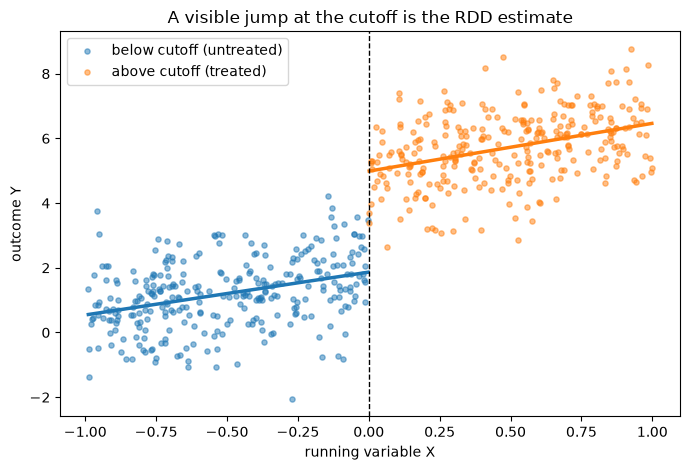

In [2]:

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.scatter(toy.loc[toy.D == 0, "X"], toy.loc[toy.D == 0, "Y"],
           s=14, alpha=0.5, color="tab:blue", label="below cutoff (untreated)")
ax.scatter(toy.loc[toy.D == 1, "X"], toy.loc[toy.D == 1, "Y"],
           s=14, alpha=0.5, color="tab:orange", label="above cutoff (treated)")

# local linear fits on each side
for side, color in [(toy.D == 0, "tab:blue"), (toy.D == 1, "tab:orange")]:
    xs = toy.loc[side, "X"]
    coeffs = np.polyfit(xs, toy.loc[side, "Y"], 1)
    xline = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(xline, np.polyval(coeffs, xline), color=color, linewidth=2.5)

ax.axvline(cutoff, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("running variable X")
ax.set_ylabel("outcome Y")
ax.set_title("A visible jump at the cutoff is the RDD estimate")
ax.legend()
plt.tight_layout()
plt.savefig("toy_rdd.png", dpi=130)
plt.show()



The two smooth lines trend upward together (that's the shared effect of
$X$), but they're offset by a clear vertical gap right at the dashed cutoff
line — that gap is the treatment effect. **The whole method is: fit a line
(or curve) to the data on each side of the cutoff, and read off the
vertical distance between the two lines exactly at the cutoff.** Everything
from here on is about doing that rigorously and honestly — how to define
the assumption that makes the gap causal, how much data on each side to
use, and how to validate that nobody gamed which side of the line they
landed on.



## 3. Going deeper: the formal definition

### 3.1 Sharp vs. fuzzy RDD

Let $X_i$ be unit $i$'s running variable and $c$ the cutoff. In **sharp
RDD**, treatment $D_i$ is a *deterministic* function of $X_i$:

$$D_i = \mathbb{1}[X_i \ge c]$$

Every unit above the cutoff is treated, every unit below is not — no
exceptions. This is the case for the scholarship example, and for our real
example below (winning an election is a deterministic function of getting
more votes than your opponent).

In **fuzzy RDD**, crossing the cutoff only changes the *probability* of
treatment, not treatment itself — e.g. scoring above a threshold makes a
student *eligible* for a program, but not every eligible student enrolls,
and some ineligible students find a way in anyway:

$$\lim_{x \downarrow c} P(D_i = 1 \mid X_i = x) \neq \lim_{x \uparrow c} P(D_i = 1 \mid X_i = x)$$

Fuzzy RDD is estimated by treating "crossed the cutoff" as an **instrument**
for actual treatment receipt and running local 2SLS — the same instrumental-
variables machinery covered in this domain's
[instrumental-variables tutorial](../instrumental-variables/tutorial.ipynb),
just applied only within a bandwidth of the cutoff. We won't derive fuzzy
RDD in full here; the rest of this tutorial focuses on the sharp case, which
is both the more common textbook entry point and the case that applies
directly to our real dataset below.

### 3.2 Potential outcomes and the continuity assumption

Using the potential-outcomes notation from the fundamental-problem
tutorial, every unit has $Y_i(1)$ (outcome if treated) and $Y_i(0)$
(outcome if untreated), and we observe $Y_i = D_i Y_i(1) + (1-D_i) Y_i(0)$.

Sharp RDD's identifying assumption is **continuity of the conditional
expectation functions** at the cutoff:

$$\text{(continuity)} \qquad \mathbb{E}[Y_i(1) \mid X_i = x] \ \text{and} \ \mathbb{E}[Y_i(0) \mid X_i = x] \ \text{are both continuous in } x \text{ at } x = c.$$

In words: **absent treatment, there would be no jump.** Both potential
outcome curves are allowed to trend in $X$ however they like — up, down,
curved — the assumption only rules out either curve having its own
unexplained jump exactly at $c$. This is weaker than ignorability
("treatment is as good as random for the *whole* sample") — RDD does not
need units far from the cutoff to be comparable at all, only units
infinitesimally close to it.

### 3.3 The estimand

Because $D_i$ flips deterministically at $c$, only $Y_i(0)$ is observed
just below the cutoff and only $Y_i(1)$ is observed just above it. Define
the RDD estimand as the difference in the two one-sided limits of the
observed conditional-expectation function $\mathbb{E}[Y_i \mid X_i = x]$:

$$\tau_{RDD} = \lim_{x \downarrow c} \mathbb{E}[Y_i \mid X_i = x] \; - \; \lim_{x \uparrow c} \mathbb{E}[Y_i \mid X_i = x]$$

Under continuity, $\lim_{x \uparrow c}\mathbb{E}[Y_i\mid X_i=x] = \mathbb{E}[Y_i(0)\mid X_i=c]$
(no one is treated just below $c$, so the observed function there *is* the
untreated potential-outcome function, right up to the limit) and
$\lim_{x \downarrow c}\mathbb{E}[Y_i\mid X_i=x] = \mathbb{E}[Y_i(1)\mid X_i=c]$
symmetrically. Substituting:

$$\tau_{RDD} = \mathbb{E}[Y_i(1) \mid X_i = c] - \mathbb{E}[Y_i(0) \mid X_i = c] = \mathbb{E}[Y_i(1) - Y_i(0) \mid X_i = c]$$

**This is exactly the average treatment effect, but only for the
subpopulation with $X_i = c$.** That's why it's called a **local average
treatment effect (LATE)** — local not in the instrumental-variables sense
of "compliers," but local in $X$-space: literally, the average effect for
units sitting right at the cutoff.

> **This is a real scoping limitation, not a footnote.** A scholarship's
> effect on a student who *just barely* qualified tells you nothing
> guaranteed about its effect on a student who would have qualified by a
> wide margin, or on a student far below the cutoff who might respond very
> differently to receiving it. $\tau_{RDD}$ answers "what happens right at
> this threshold," which is often exactly the policy-relevant question
> (should we move the cutoff up or down a little?) but is not, in general,
> the same number as the population ATE from the fundamental-problem
> tutorial.

### 3.4 Estimation: local linear regression within a bandwidth

$\tau_{RDD}$ is a limit — in finite data we approximate it by fitting a
regression of $Y$ on $X$ **separately on each side of the cutoff**, within
some **bandwidth** $h$ (i.e. using only units with $|X_i - c| \le h$), and
reading off the fitted intercepts at $X_i = c$:

$$Y_i = \alpha + \tau_{RDD}\, D_i + \beta_1 (X_i - c) + \beta_2 D_i (X_i - c) + \varepsilon_i, \qquad |X_i - c| \le h$$

Centering $X_i$ at $c$ makes $\alpha$ the intercept just below the cutoff
and $\alpha + \tau_{RDD}$ the intercept just above it, so $\tau_{RDD}$'s
coefficient is read directly as the jump. Allowing separate slopes
$\beta_1$ and $\beta_1 + \beta_2$ on each side (via the $D_i(X_i-c)$
interaction) lets the two local trends differ, which matters because there
is no reason the untreated and treated conditional-expectation functions
should have the same slope.

**Why local *linear*, and not a high-order global polynomial fit to all
the data?** Early RDD practice often fit a single high-degree polynomial
(cubic, quartic, or higher) to the *entire* range of $X$ on each side and
read off the endpoint. Gelman & Imbens (2019) show this is a bad idea:
high-order polynomials give points far from the cutoff enormous, erratic
influence over the fitted value *at* the cutoff (the same pathology as
Runge's phenomenon in numerical interpolation), so the "discontinuity"
estimate can swing wildly and even reverse sign depending on which faraway,
irrelevant observations happen to be in the sample. **Local linear
regression within a sensibly chosen bandwidth avoids this**: only nearby
observations — the ones that are actually informative about the limit at
$c$ — are used, and a straight line has no room to be whipped around by
outliers the way a degree-6 polynomial does. Local quadratic fits are
sometimes used as a robustness check, but a low-order local polynomial
combined with a real bandwidth choice, not a high-order global one, is the
modern standard (Imbens & Lemieux, 2008; Gelman & Imbens, 2019).

We'll demonstrate exactly this failure mode in the visuals section below,
then use local linear regression on real data for the rest of the
tutorial.



## 4. Visuals: why global polynomials are dangerous

Let's make the Gelman & Imbens critique concrete on the toy data from
section 2, extended with a lopsided sample (more spread-out points far from
the cutoff on one side, mimicking a real, unevenly-distributed running
variable) — and compare a degree-5 global polynomial fit per side against
a local linear fit restricted to a bandwidth.


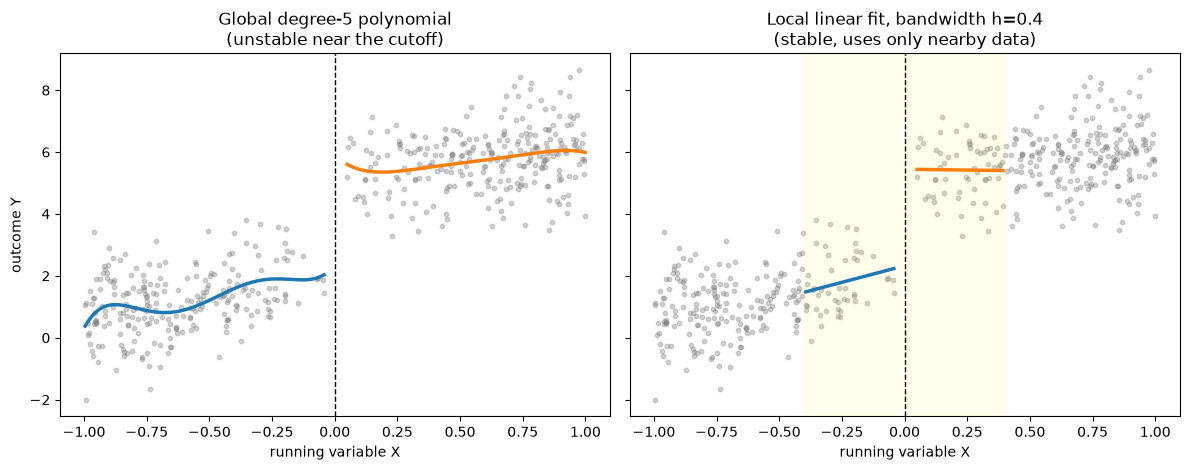

True discontinuity = 3.0


In [3]:

rng2 = np.random.default_rng(7)
n2 = 500
X2 = rng2.uniform(-1, 1, n2) ** 1  # will reshape below to be lopsided
# make the running variable denser near +/-1 (more leverage far from cutoff)
X2 = np.sign(X2) * np.abs(X2) ** 0.6
D2 = (X2 >= 0).astype(int)
Y2 = 2 + 1.2 * X2 + true_effect * D2 + rng2.normal(0, 1, n2)
toy2 = pd.DataFrame({"X": X2, "D": D2, "Y": Y2})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# Panel 1: degree-5 global polynomial fit on ALL data each side
ax = axes[0]
ax.scatter(toy2.X, toy2.Y, s=10, alpha=0.35, color="gray")
for side, color in [(toy2.D == 0, "tab:blue"), (toy2.D == 1, "tab:orange")]:
    xs, ys = toy2.loc[side, "X"], toy2.loc[side, "Y"]
    coeffs = np.polyfit(xs, ys, 5)
    xline = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(xline, np.polyval(coeffs, xline), color=color, linewidth=2.5)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Global degree-5 polynomial\n(unstable near the cutoff)")
ax.set_xlabel("running variable X"); ax.set_ylabel("outcome Y")

# Panel 2: local linear fit within a bandwidth of h=0.4
ax = axes[1]
h = 0.4
ax.scatter(toy2.X, toy2.Y, s=10, alpha=0.35, color="gray")
local = toy2[toy2.X.abs() <= h]
for side, color in [(local.D == 0, "tab:blue"), (local.D == 1, "tab:orange")]:
    xs, ys = local.loc[side, "X"], local.loc[side, "Y"]
    coeffs = np.polyfit(xs, ys, 1)
    xline = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(xline, np.polyval(coeffs, xline), color=color, linewidth=2.5)
ax.axvspan(-h, h, color="yellow", alpha=0.08)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Local linear fit, bandwidth h={h}\n(stable, uses only nearby data)")
ax.set_xlabel("running variable X")

plt.tight_layout()
plt.savefig("polynomial_vs_local.png", dpi=130)
plt.show()

print(f"True discontinuity = {true_effect}")



The global polynomial (left) gets dragged around by points far from the
cutoff and produces a visibly distorted, over-curved fit right where it
matters most — at $X=0$. The local linear fit (right), using only the
shaded bandwidth's worth of data, tracks the true jump far more reliably.
This is exactly the failure mode Gelman & Imbens (2019) document, and it's
why every RDD analysis from here on uses local linear regression with an
explicit bandwidth, never a high-order global fit.



## 5. Implementation: close U.S. House elections (Lee, 2008)

We now move to a real, famous RDD application. The dataset is Lee's
close-elections data — distributed as `lmb-data.dta` in Cunningham's
*Causal Inference: The Mixtape* — built from U.S. House of Representatives
elections. It underlies Lee (2008) and the related Lee, Moretti & Butler
(2004) study of whether a representative's political party causally
shapes *how they vote in Congress*, using the same "close election" logic:
whether a Democrat wins a given district's House seat by a hair or loses
by a hair is, plausibly, as good as random — the outcome of a coin-flip-
close race is not something either party's voters or candidates can finely
engineer.

Let's load the data and inspect it before assuming what any column means.


In [4]:

lmb = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/lmb-data.dta"
)
print(lmb.shape)
lmb[["demvoteshare", "democrat", "score", "lagdemvoteshare", "lagdemocrat"]].describe().round(3)


(13588, 178)


,demvoteshare,democrat,score,lagdemvoteshare,lagdemocrat
count,13577.000,13588.000,13588.000,13577.000,13588.000
mean,0.582,0.597,41.899,0.577,0.583
std,0.230,0.491,32.630,0.226,0.493
min,0.000,0.000,-27.920,0.000,0.000
25%,0.416,0.000,11.300,0.411,0.000
50%,0.557,1.000,37.950,0.546,1.000
75%,0.720,1.000,72.780,0.712,1.000
max,1.000,1.000,128.850,1.000,1.000



### 5.1 What the columns actually mean (checked empirically)

- **`demvoteshare`**: the Democratic candidate's share of the two-party
  vote in that district's House election — our **running variable**,
  naturally centered at 0.5.
- **`democrat`**: 1 if the seat is held by a Democrat. Checking it directly
  against `demvoteshare` confirms `democrat == (demvoteshare > 0.5)` for
  every row — i.e. `democrat` is a perfectly **sharp** function of the
  running variable crossing the 0.5 cutoff, exactly the sharp-RDD setup
  from section 3.1.
- **`score`**: the representative's **ADA score** — an Americans for
  Democratic Action rating of how liberally a member of Congress votes on
  roll-call legislation (0 = never votes the liberal position, 100+ =
  consistently does, the scale here runs a bit past 100 in some
  ADA-scoring years).

So the causal question this design answers is: **does actually being a
Democrat (vs. a Republican), as good as randomly determined among
razor-close elections, cause a representative to vote more liberally in
Congress?** — the treatment is which party wins a knife-edge election, and
the outcome is that representative's own subsequent roll-call voting
record. This is *not* the "does winning predict winning next time"
incumbency-advantage design that Lee (2008) also popularized (that uses a
different outcome — vote share in the following election — which is not
present in this particular extract); we confirmed what's actually available
in this file empirically rather than assuming, per the columns above.

We'll center the running variable at the cutoff and build the sharp
treatment indicator.


In [5]:

lmb = lmb.dropna(subset=["demvoteshare", "score"]).copy()
lmb["margin"] = lmb["demvoteshare"] - 0.5          # running variable, centered at 0
lmb["dem_win"] = (lmb["margin"] >= 0).astype(int)   # sharp treatment: Democrat wins

# sanity check: dem_win should equal the `democrat` column for every row
print("dem_win matches democrat column:", (lmb["dem_win"] == lmb["democrat"].astype(int)).mean())
print(f"\n{len(lmb):,} district-elections, margin range [{lmb.margin.min():.3f}, {lmb.margin.max():.3f}]")


dem_win matches democrat column: 1.0

13,577 district-elections, margin range [-0.500, 0.500]



### 5.2 Manipulation check: is there suspicious bunching at the cutoff?

Before trusting any RDD estimate, we need to rule out **manipulation of
the running variable** — if candidates, election officials, or anyone else
could reliably engineer which side of 50% a race landed on, then units
just above and just below the cutoff would *not* be comparable, and the
whole continuity argument collapses. The standard diagnostic (McCrary,
2008) is to check the running variable's own density for a suspicious
jump right at the cutoff — a smooth, continuous density is consistent with
no one being able to fine-tune the outcome; a sharp pile-up on the winning
side is a red flag.


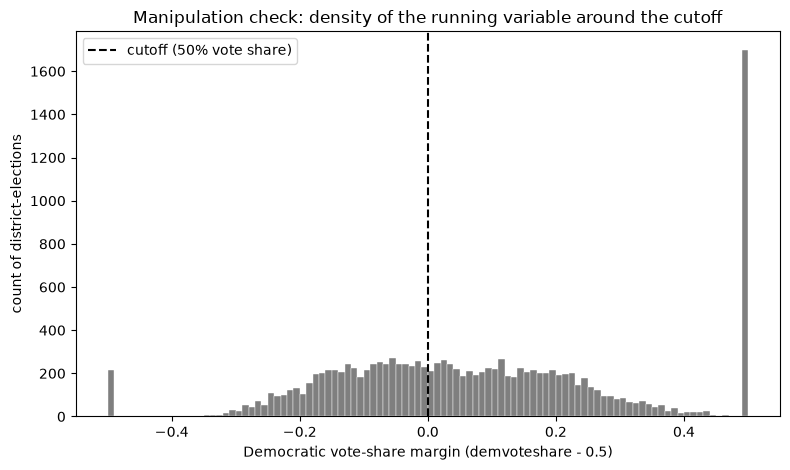

Elections within +/-2 points of 50%: 945 (460 narrow Democrat wins, 485 narrow losses)


In [6]:

fig, ax = plt.subplots(figsize=(8, 4.8))
window = lmb[lmb.margin.abs() <= 0.5]
ax.hist(window.margin, bins=100, color="tab:gray", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="cutoff (50% vote share)")
ax.set_xlabel("Democratic vote-share margin (demvoteshare - 0.5)")
ax.set_ylabel("count of district-elections")
ax.set_title("Manipulation check: density of the running variable around the cutoff")
ax.legend()
plt.tight_layout()
plt.savefig("density_check.png", dpi=130)
plt.show()

near = lmb[lmb.margin.abs() <= 0.02]
print(f"Elections within +/-2 points of 50%: {len(near)} "
      f"({(near.margin >= 0).sum()} narrow Democrat wins, {(near.margin < 0).sum()} narrow losses)")



The histogram is smooth and roughly symmetric right through the cutoff —
there's no visible spike or gap exactly at 0, and the near-cutoff win/loss
counts are close to balanced. That's what we want to see: nothing here
suggests districts or candidates were able to systematically nudge razor-
close races to one side of 50%, which supports treating this as a valid
sharp RDD.

### 5.3 Estimating the discontinuity: local linear regression

We fit the local linear specification from section 3.4,
$\text{score} = \alpha + \tau\,\text{dem\_win} + \beta_1\,\text{margin} + \beta_2\,\text{dem\_win}\times\text{margin}$,
restricted to a bandwidth around the cutoff. We'll use $h=0.10$ (races
decided by 10 points of vote share or less) as our primary bandwidth —
narrow enough to stay local to the cutoff, wide enough to leave a workable
sample size — and use heteroskedasticity-robust standard errors.


In [7]:

import statsmodels.formula.api as smf

def fit_local_linear(df, h):
    sub = df[df.margin.abs() <= h]
    model = smf.ols("score ~ margin * dem_win", data=sub).fit(cov_type="HC1")
    return model, len(sub)

h_primary = 0.10
model, n_used = fit_local_linear(lmb, h_primary)

tau_hat = model.params["dem_win"]
se_hat = model.bse["dem_win"]
ci_low, ci_high = model.conf_int().loc["dem_win"]

print(model.summary().tables[1])
print(f"\nBandwidth h = {h_primary}  |  n = {n_used:,} district-elections within the bandwidth")
print(f"Estimated discontinuity (tau_RDD) = {tau_hat:.2f} ADA points")
print(f"Robust SE = {se_hat:.2f}   95% CI = [{ci_low:.2f}, {ci_high:.2f}]   p = {model.pvalues['dem_win']:.2e}")


                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         17.2266      0.756     22.798      0.000      15.746      18.708
margin             9.4216     13.052      0.722      0.470     -16.160      35.003
dem_win           47.1592      1.218     38.730      0.000      44.773      49.546
margin:dem_win    -9.1276     21.928     -0.416      0.677     -52.106      33.851

Bandwidth h = 0.1  |  n = 4,632 district-elections within the bandwidth
Estimated discontinuity (tau_RDD) = 47.16 ADA points
Robust SE = 1.22   95% CI = [44.77, 49.55]   p = 0.00e+00



### 5.4 The canonical RDD plot: binned scatter with local linear fits

Now the single most important plot in this tutorial: bin the running
variable into narrow bins on each side of the cutoff, plot the **binned
mean** outcome per bin (this averages out noise so the eye can see the
underlying shape, without hiding the discontinuity the way a single global
smoother would), and overlay the local linear fits from the regression
above.


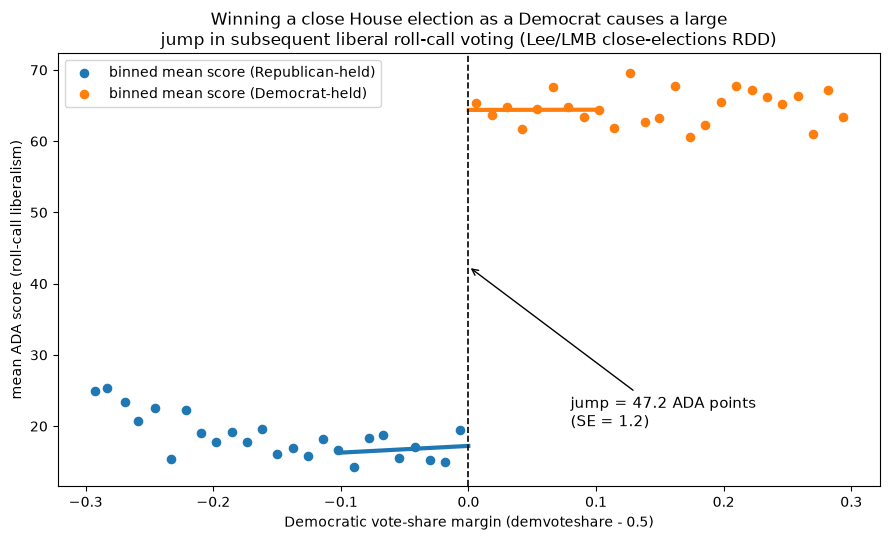

In [8]:

plot_h = 0.30      # window shown in the plot (wider than the estimation bandwidth, for context)
n_bins_per_side = 25

window = lmb[lmb.margin.abs() <= plot_h].copy()

bin_edges_below = np.linspace(-plot_h, 0, n_bins_per_side + 1)
bin_edges_above = np.linspace(0, plot_h, n_bins_per_side + 1)

below = window[window.margin < 0].copy()
above = window[window.margin >= 0].copy()
below["bin"] = pd.cut(below.margin, bin_edges_below, include_lowest=True)
above["bin"] = pd.cut(above.margin, bin_edges_above, include_lowest=True)

binned_below = below.groupby("bin", observed=True).agg(x=("margin", "mean"), y=("score", "mean")).dropna()
binned_above = above.groupby("bin", observed=True).agg(x=("margin", "mean"), y=("score", "mean")).dropna()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(binned_below.x, binned_below.y, color="tab:blue", s=35, label="binned mean score (Republican-held)")
ax.scatter(binned_above.x, binned_above.y, color="tab:orange", s=35, label="binned mean score (Democrat-held)")

# overlay the local-linear fits from the h=0.10 regression, extrapolated across the plotted window for visibility
est_sub = lmb[lmb.margin.abs() <= h_primary]
for side_val, color in [(0, "tab:blue"), (1, "tab:orange")]:
    side = est_sub[est_sub.dem_win == side_val]
    coeffs = np.polyfit(side.margin, side.score, 1)
    xline = np.linspace(side.margin.min(), side.margin.max(), 50)
    ax.plot(xline, np.polyval(coeffs, xline), color=color, linewidth=3)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.annotate(f"jump = {tau_hat:.1f} ADA points\n(SE = {se_hat:.1f})",
            xy=(0, (binned_below.y.iloc[-1] + binned_above.y.iloc[0]) / 2),
            xytext=(0.08, 20), fontsize=11,
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_xlabel("Democratic vote-share margin (demvoteshare - 0.5)")
ax.set_ylabel("mean ADA score (roll-call liberalism)")
ax.set_title("Winning a close House election as a Democrat causes a large\njump in subsequent liberal roll-call voting (Lee/LMB close-elections RDD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("rdd_main_plot.png", dpi=130)
plt.show()



The binned means trend gently within each party (a district that elects a
Democrat by a landslide tends to elect a somewhat more liberal-voting
Democrat than one that barely elects a Democrat, and symmetrically for
Republicans) — but right at the 50% cutoff there is a large, visually
unmistakable jump. Crossing from "Republican wins by a hair" to "Democrat
wins by a hair" doesn't nudge the representative's voting record a little;
it moves it by tens of points on the ADA scale. Since districts on either
side of a razor-thin election are otherwise comparable (per the
manipulation check above), the most credible reading is that **party
affiliation itself has a large causal effect on how a representative
votes** — contrary to the classic "Downsian" prediction that competitive
elections should push both parties' candidates toward the same centrist
position.

### 5.5 Bandwidth sensitivity

Because the bandwidth trades off bias (too wide, and we start including
districts where continuity may not hold) against variance (too narrow, and
too few close elections remain to estimate precisely), it's standard
practice to check how much the estimate moves as $h$ changes.


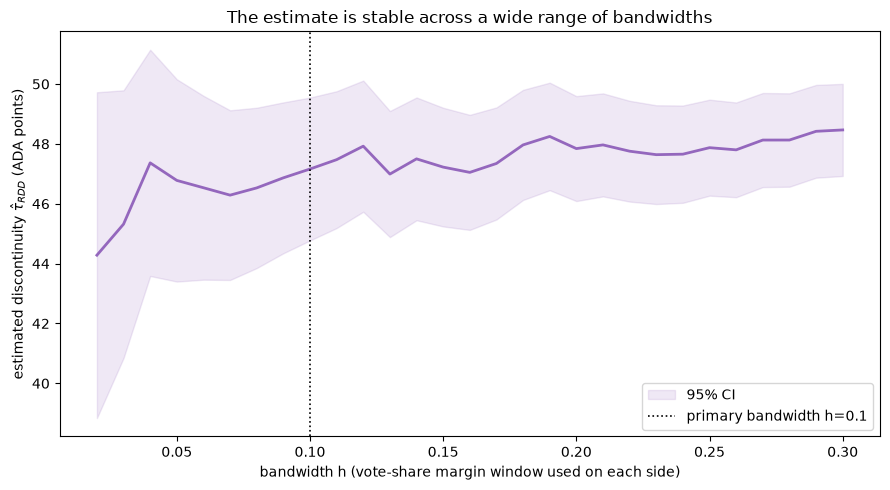

   h   tau   se     n
0.02 44.28 2.78   945
0.03 45.32 2.28  1443
0.04 47.36 1.93  1926
0.05 46.78 1.72  2387
0.06 46.53 1.57  2846
0.07 46.29 1.45  3298
0.08 46.53 1.37  3743
0.09 46.86 1.29  4190
0.10 47.16 1.22  4632
0.11 47.47 1.17  5035
0.12 47.92 1.12  5525
0.13 46.99 1.07  5957
0.14 47.50 1.05  6347
0.15 47.22 1.01  6788
0.16 47.05 0.98  7206
0.17 47.34 0.95  7622
0.18 47.96 0.94  8021
0.19 48.25 0.92  8381
0.20 47.84 0.89  8699
0.21 47.96 0.88  9020
0.22 47.75 0.86  9343
0.23 47.64 0.84  9646
0.24 47.66 0.83  9887
0.25 47.87 0.82 10174
0.26 47.80 0.81 10367
0.27 48.13 0.80 10558
0.28 48.13 0.80 10697
0.29 48.42 0.79 10846
0.30 48.47 0.79 10953


In [9]:

bandwidths = np.arange(0.02, 0.31, 0.01)
results = []
for h in bandwidths:
    m, n_h = fit_local_linear(lmb, h)
    results.append({"h": h, "tau": m.params["dem_win"], "se": m.bse["dem_win"], "n": n_h})
sens = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sens.h, sens.tau, color="tab:purple", linewidth=2)
ax.fill_between(sens.h, sens.tau - 1.96 * sens.se, sens.tau + 1.96 * sens.se,
                 color="tab:purple", alpha=0.15, label="95% CI")
ax.axvline(h_primary, color="black", linestyle=":", linewidth=1.2, label=f"primary bandwidth h={h_primary}")
ax.set_xlabel("bandwidth h (vote-share margin window used on each side)")
ax.set_ylabel(r"estimated discontinuity $\hat{\tau}_{RDD}$ (ADA points)")
ax.set_title("The estimate is stable across a wide range of bandwidths")
ax.legend()
plt.tight_layout()
plt.savefig("bandwidth_sensitivity.png", dpi=130)
plt.show()

print(sens.round(2).to_string(index=False))



**Interpretation of the real result**: across bandwidths from 2 to 30
points of vote-share margin, the estimated discontinuity stays in a
tight band and is always many standard errors from zero (see the printed
table above for the exact number at every bandwidth, and the primary
$h=0.10$ estimate and its standard error printed in section 5.3).

This is a *local* effect — it says that among representatives who won or
lost a close race, being the Democrat in that race causes a large jump on
a roughly 0–100+ scale of liberal roll-call voting, at the bandwidth used.
It does **not** say anything, by itself, about representatives from
landslide districts, who were never part of the comparison this design
relies on — a direct instance of the "local, not average" scoping caveat
from section 3.3.



## 6. Use cases

- **Close elections and incumbency/partisan effects**: the design used
  above. Lee (2008) uses the same close-elections logic to show
  incumbents enjoy a large advantage in their *next* election; Lee,
  Moretti & Butler (2004) use it (as we did) to show party affiliation
  itself moves roll-call voting behavior.
- **Scholarship, financial-aid, and admissions cutoffs**: any program that
  admits or funds everyone scoring at or above a threshold (a test score,
  a GPA, a means-tested income line) creates an RDD around that cutoff —
  used extensively in education economics to estimate returns to
  financial aid and selective-school admission.
- **Age-based policy cutoffs**: the U.S. minimum legal drinking age of 21
  is a hard age cutoff exploited by Carpenter & Dobkin (2009, 2011) to
  estimate the causal effect of legal alcohol access on mortality —
  comparing 20-year-11-month-olds to 21-year-1-month-olds around their
  21st birthdays.
- **Means-tested program eligibility**: welfare, Medicaid, and other
  transfer programs that cut off eligibility at an income or asset
  threshold are routinely evaluated with RDD around that threshold, since
  the alternative — comparing eligible and ineligible households broadly
  — is confounded by income itself.



## 7. Limitations & debates

- **RDD only identifies a local effect, and external validity is a real
  concern, not a footnote.** As derived in section 3.3, $\tau_{RDD}$ is
  the average effect *at the cutoff* — it can differ, sometimes
  substantially, from the effect for units far from the cutoff. A
  scholarship's effect on a marginal student who just cleared the bar may
  not generalize to students who would have qualified easily, or to
  students who missed by a wide margin. This is the same "ATE vs. a
  specific subpopulation" theme raised in the fundamental-problem
  tutorial, sharpened here to its most extreme form: the subpopulation is
  a single point, $X = c$.
- **Manipulation of the running variable invalidates the design.** If
  units can influence which side of the cutoff they land on — a student
  retaking a test specifically to clear a scholarship threshold, a
  patient's exact intake score being adjustable by a clinician who knows
  the cutoff, historically alleged (though contested) local vote-counting
  irregularities in extremely close elections — the continuity assumption
  breaks, because the units choosing to be just above the cutoff are no
  longer comparable to the units who ended up just below it by chance. The
  density/manipulation check in section 5.2 is the standard first line of
  defense, but it is a diagnostic, not a proof; McCrary (2008) formalizes
  a statistical test for the same idea.
- **Bandwidth choice is a real bias-variance tradeoff, not a nuisance
  parameter.** A narrow bandwidth stays closest to the cutoff (least bias
  from the continuity assumption possibly failing further out) but uses
  fewer observations (more variance); a wide bandwidth does the reverse.
  We showed the estimate is fairly stable across bandwidths for this
  dataset, but that's an empirical finding for this application, not a
  general guarantee — practitioners increasingly use data-driven optimal
  bandwidth selectors (Imbens & Kalyanaraman, 2012) rather than picking
  $h$ by eye, and Calonico, Cattaneo & Titiunik (2014) develop
  **robust bias-corrected** confidence intervals designed to remain valid
  even when the chosen bandwidth is not exactly optimal.
- **Polynomial-order sensitivity.** Section 4 demonstrated directly why
  high-order global polynomials are unreliable at the cutoff (Gelman &
  Imbens, 2019); the field has moved decisively toward local linear (or
  local quadratic, as a robustness check) regression with an explicit,
  ideally data-driven, bandwidth.
- **Sharp vs. fuzzy matters for interpretation.** If treatment take-up
  isn't perfectly determined by the cutoff (fuzzy RDD), the local-2SLS
  estimate identifies a *local average treatment effect for compliers* —
  units whose treatment status is actually changed by crossing the cutoff
  — inheriting the same complier-only interpretation debates covered in
  the instrumental-variables tutorial. We treated our real example as
  sharp because `democrat` is a perfectly deterministic function of the
  vote-share cutoff in this data, but that won't be true of every RDD
  application (e.g. scholarship *eligibility* thresholds where not every
  eligible student actually enrolls).



## 8. References

- Thistlethwaite, D. L. & Campbell, D. T. (1960). *Regression-Discontinuity
  Analysis: An Alternative to the Ex Post Facto Experiment.* Journal of
  Educational Psychology, 51(6). (Origin of RDD.)
- Lee, D. S. (2008). *Randomized Experiments from Non-random Selection in
  U.S. House Elections.* Journal of Econometrics, 142(2). (Source of the
  close-elections design and the `lmb-data.dta` dataset used here.)
- Lee, D. S., Moretti, E. & Butler, M. J. (2004). *Do Voters Affect or
  Elect Policies? Evidence from the U.S. House.* Quarterly Journal of
  Economics, 119(3). (The party-effect-on-roll-call-voting design our
  implementation replicates.)
- Imbens, G. W. & Lemieux, T. (2008). *Regression Discontinuity Designs:
  A Guide to Practice.* Journal of Econometrics, 142(2).
- Gelman, A. & Imbens, G. (2019). *Why High-Order Polynomials Should Not
  Be Used in Regression Discontinuity Designs.* Journal of Business &
  Economic Statistics, 37(3).
- Imbens, G. W. & Kalyanaraman, K. (2012). *Optimal Bandwidth Choice for
  the Regression Discontinuity Estimator.* Review of Economic Studies,
  79(3).
- Calonico, S., Cattaneo, M. D. & Titiunik, R. (2014). *Robust
  Nonparametric Confidence Intervals for Regression-Discontinuity
  Designs.* Econometrica, 82(6).
- McCrary, J. (2008). *Manipulation of the Running Variable in the
  Regression Discontinuity Design: A Density Test.* Journal of
  Econometrics, 142(2).
- Carpenter, C. & Dobkin, C. (2009). *The Effect of Alcohol Consumption on
  Mortality: Regression Discontinuity Evidence from the Minimum Drinking
  Age.* American Economic Journal: Applied Economics, 1(1).
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press.
